# Airbnb Multi-City Analysis — Notebook 01: Data Understanding

## 1. Business Context

This project analyzes Airbnb listing data from multiple major cities in order to extract business-relevant insights, identify structural patterns, detect anomalies, and prepare the analytical foundation for data visualization and modeling.

The final goal is to build a robust analytical workflow that supports:
- exploratory analysis,
- statistical validation of hypotheses,
- predictive or segmentation modeling,
- and business-facing dashboard development in Power BI.

## 2. Notebook Objective

The objective of this notebook is to perform an initial professional data understanding phase. Specifically, this notebook focuses on:

- loading and organizing the available datasets,
- identifying schema differences across cities,
- reviewing data dimensions and variable types,
- evaluating data quality issues such as null values and duplicates,
- and documenting the main technical findings that will guide preprocessing.

This notebook does **not** perform full cleaning or modeling. Its purpose is to establish a solid and documented starting point for the rest of the project.

In [17]:
# Standard libraries
import os
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Project Scope

The analysis is based on Airbnb listing datasets from multiple cities.  
At this stage, the goal is to inspect the raw data structure before any major transformation is applied.

The cities included in this project are:
- Madrid
- Milan
- London
- New York
- Sydney
- Tokyo

A multi-city setup is especially valuable because it allows:
- cross-city comparison,
- detection of structural differences,
- and richer business insights for final reporting and dashboarding.

In [15]:
df_madrid_csv = pd.read_csv("../data/raw/madrid_airbnb.csv")
df_madrid_xlsx = pd.read_excel("../data/raw/madrid_airbnb.xlsx")

df_london_csv = pd.read_csv("../data/raw/london_airbnb.csv")
df_london_xlsx = pd.read_excel("../data/raw/london_airbnb.xlsx")

df_milan_csv = pd.read_csv("../data/raw/milan_airbnb.csv")
df_milan_xlsx = pd.read_excel("../data/raw/milan_airbnb.xlsx")

df_ny = pd.read_csv("../data/raw/NY_airbnb.csv")
df_sydney = pd.read_csv("../data/raw/sydney_airbnb.csv")
df_tokyo = pd.read_csv("../data/raw/tokyo_airbnb.csv")

In [16]:
# =========================
# COMPARACIÓN DE DATASETS DUPLICADOS
# =========================

datasets = {
    "Madrid": (df_madrid_csv, df_madrid_xlsx),
    "London": (df_london_csv, df_london_xlsx),
    "Milan": (df_milan_csv, df_milan_xlsx)
}

for city, (df_csv, df_xlsx) in datasets.items():
    print(f"\n--- {city} ---")
    print("Shape CSV:", df_csv.shape)
    print("Shape XLSX:", df_xlsx.shape)
    print("Mismas columnas:", set(df_csv.columns) == set(df_xlsx.columns))
    print("Iguales exactos:", df_csv.equals(df_xlsx))


--- Madrid ---
Shape CSV: (19618, 16)
Shape XLSX: (19618, 16)
Mismas columnas: True
Iguales exactos: False

--- London ---
Shape CSV: (85068, 16)
Shape XLSX: (85068, 16)
Mismas columnas: True
Iguales exactos: False

--- Milan ---
Shape CSV: (18322, 15)
Shape XLSX: (18322, 15)
Mismas columnas: True
Iguales exactos: False


In [23]:
data_files = {
    "Madrid": "../data/raw/madrid_airbnb.csv",
    "Milan": "../data/raw/milan_airbnb.csv",
    "London": "../data/raw/london_airbnb.csv",
    "New_York": "../data/raw/NY_airbnb.csv",
    "Sydney": "../data/raw/sydney_airbnb.csv",
    "Tokyo": "../data/raw/tokyo_airbnb.csv",
}

In [24]:
file_check = pd.DataFrame(
    {
        "city": list(data_files.keys()),
        "path": list(data_files.values()),
        "exists": [os.path.exists(path) for path in data_files.values()]
    }
)

file_check

,city,path,exists
0,Madrid,../data/raw/madrid_airbnb.csv,True
1,Milan,../data/raw/milan_airbnb.csv,True
2,London,../data/raw/london_airbnb.csv,True
3,New_York,../data/raw/NY_airbnb.csv,True
4,Sydney,../data/raw/sydney_airbnb.csv,True
5,Tokyo,../data/raw/tokyo_airbnb.csv,True


## 2. Data Loading

Each city dataset is loaded independently and stored in a dictionary structure.  
This allows us to inspect and validate the datasets separately before creating a unified dataset.

In addition, a `city` column is appended to each DataFrame in order to preserve origin when datasets are later concatenated.

In [ ]:
dfs = {}

for city, path in data_files.items():   
    df = pd.read_csv(path)
    df["city"] = city
    dfs[city] = df

print(f"Datasets loaded successfully: {len(dfs)}")
print("Cities loaded:", ", ".join(dfs.keys()))

Datasets loaded successfully: 6
Cities loaded: Madrid, Milan, London, New_York, Sydney, Tokyo


## 3. Dataset Dimensions

The first structural inspection consists of reviewing the number of rows and columns available in each dataset.

This helps answer several relevant questions:
- Which city has the largest dataset?
- Are all datasets structurally similar?
- Do some cities already suggest schema inconsistencies?

In [26]:
shape_summary = pd.DataFrame(
    [
        {
            "city": city,
            "rows": df.shape[0],
            "columns": df.shape[1]
        }
        for city, df in dfs.items()
    ]
).sort_values(by="rows", ascending=False)

shape_summary

,city,rows,columns
2,London,85068,17
3,New_York,48895,17
4,Sydney,36662,17
0,Madrid,19618,17
1,Milan,18322,16
5,Tokyo,11466,15


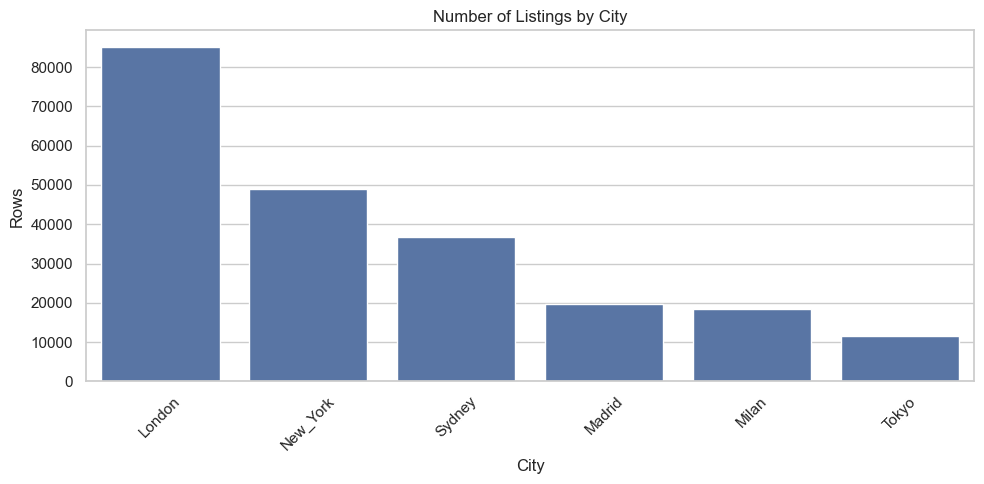

In [27]:
plt.figure(figsize=(10, 5))
sns.barplot(data=shape_summary, x="city", y="rows")
plt.title("Number of Listings by City")
plt.xlabel("City")
plt.ylabel("Rows")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Initial observation

The cities do not all have the same number of observations, which is expected in real-world marketplace data.

However, there are also differences in the number of columns across datasets.  
This suggests that the schema is not fully standardized and will need to be harmonized before a full cross-city analysis can be performed.

## 4. Schema Inspection

A professional data understanding phase must verify whether all datasets share the same variables.

To assess schema consistency, we inspect:
- the list of columns in each city dataset,
- the variables shared by all cities,
- and the variables available only in specific subsets of cities.

In [28]:
for city, df in dfs.items():
    print("=" * 100)
    print(f"{city} | total columns: {len(df.columns)}")
    print("-" * 100)
    print(df.columns.tolist())
    print()

Madrid | total columns: 17
----------------------------------------------------------------------------------------------------
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'city']

Milan | total columns: 16
----------------------------------------------------------------------------------------------------
['id', 'name', 'host_id', 'host_name', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'city']

London | total columns: 17
----------------------------------------------------------------------------------------------------
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_ty

In [29]:
all_columns = sorted(set().union(*[set(df.columns) for df in dfs.values()]))

schema_matrix = pd.DataFrame(index=all_columns)

for city, df in dfs.items():
    schema_matrix[city] = schema_matrix.index.isin(df.columns)

schema_matrix

,Madrid,Milan,London,New_York,Sydney,Tokyo
availability_365,True,True,True,True,True,False
calculated_host_listings_count,True,True,True,True,True,False
city,True,True,True,True,True,True
host_id,True,True,True,True,True,True
host_name,True,True,True,True,True,True
id,True,True,True,True,True,True
last_review,True,True,True,True,True,True
latitude,True,True,True,True,True,True
longitude,True,True,True,True,True,True
minimum_nights,True,True,True,True,True,True


### Technical interpretation

The schema comparison confirms that the datasets are **not fully homogeneous**.

Some variables are common across nearly all cities and are strong candidates for the future common analytical schema.  
Other variables are either missing in one or more cities or appear only in a subset of datasets.

This has direct implications for preprocessing:
- a harmonized schema must be defined,
- city-specific variables may need conditional handling,
- and some analyses may only be possible on a subset of cities.

## 5. Preview of Raw Data

Before evaluating data quality in detail, it is useful to inspect a small sample of rows for each city.

This helps us understand:
- naming conventions,
- variable formats,
- raw values,
- and potential inconsistencies not obvious from schema inspection alone.

In [30]:
for city, df in dfs.items():
    print("=" * 120)
    print(f"{city} - Sample rows")
    display(df.head(3))

Madrid - Sample rows


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,6369,"Rooftop terrace room , ensuite bathroom",13660,Simon,Chamartín,Hispanoamérica,40.46,-3.68,Private room,60,1,78,2020-09-20,0.58,1,180,Madrid
1,21853,Bright and airy room,83531,Abdel,Latina,Cármenes,40.40,-3.74,Private room,31,4,33,2018-07-15,0.42,2,364,Madrid
2,23001,Apartmento Arganzuela- Madrid Rio,82175,Jesus,Arganzuela,Legazpi,40.39,-3.70,Entire home/apt,50,15,0,NaN,NaN,7,1,Madrid


Milan - Sample rows


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,6400,The Studio Milan,13822,Francesca,TIBALDI,45.44,9.18,Private room,100,4,12,19/04/10,0.14,1,358,Milan
1,23986,""" Characteristic Milanese flat""",95941,Jeremy,NAVIGLI,45.45,9.17,Entire home/apt,150,1,15,07/09/20,0.21,1,363,Milan
2,28300,nice flat near the park,121663,Marta,SARPI,45.48,9.17,Private room,180,1,8,22/04/12,0.11,1,365,Milan


London - Sample rows


...

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365,New_York
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,New_York
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaN,NaN,1,365,New_York


Sydney - Sample rows


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,12351,Sydney City & Harbour at the door,17061,Stuart,NaN,Sydney,-33.87,151.19,Private room,100,2,493,2018-11-21,4.83,2,187,Sydney
1,14250,Manly Harbour House,55948,Heidi,NaN,Manly,-33.80,151.26,Entire home/apt,471,5,1,2016-01-02,0.03,2,321,Sydney
2,15253,Stunning Penthouse Apartment In Heart Of The City,59850,Morag,NaN,Sydney,-33.88,151.22,Private room,109,2,300,2018-11-16,3.63,2,316,Sydney


Tokyo - Sample rows


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,city
0,35303,"La Casa Gaienmae C Harajuku, Omotesando is nearby",151977,Miyuki,NaN,Shibuya Ku,35.67,139.71,Private room,4196,28,18,2018-07-28,0.20,Tokyo
1,197677,Oshiage Holiday Apartment,964081,Yoshimi & Marek,NaN,Sumida Ku,35.72,139.83,Entire home/apt,10975,3,156,2019-05-21,1.65,Tokyo
2,289597,Private apt in central Tokyo #203,341577,Hide&Kei,NaN,Nerima Ku,35.74,139.66,Entire home/apt,4196,30,107,2019-05-25,1.25,Tokyo


## 6. Data Type Review

Checking data types is essential before any downstream analysis.

At this stage, we want to identify:
- numerical variables stored as objects,
- date fields requiring parsing,
- and categorical variables that may need standardization later.

In [31]:
dtype_summary = []

for city, df in dfs.items():
    temp = df.dtypes.reset_index()
    temp.columns = ["column", "dtype"]
    temp["city"] = city
    dtype_summary.append(temp)

dtype_summary = pd.concat(dtype_summary, ignore_index=True)
dtype_summary.head(20)

,column,dtype,city
0,id,int64,Madrid
1,name,str,Madrid
2,host_id,int64,Madrid
3,host_name,str,Madrid
4,neighbourhood_group,str,Madrid
5,neighbourhood,str,Madrid
6,latitude,float64,Madrid
7,longitude,float64,Madrid
8,room_type,str,Madrid
9,price,int64,Madrid


In [32]:
dtype_pivot = dtype_summary.pivot_table(
    index="column",
    columns="city",
    values="dtype",
    aggfunc="first"
)

dtype_pivot

city,London,Madrid,Milan,New_York,Sydney,Tokyo
column,,,,,,
availability_365,int64,int64,int64,int64,int64,NaN
calculated_host_listings_count,int64,int64,int64,int64,int64,NaN
city,str,str,str,str,str,str
host_id,int64,int64,int64,int64,int64,int64
host_name,str,str,str,str,str,str
id,int64,int64,int64,int64,int64,int64
last_review,str,str,str,str,str,str
latitude,float64,float64,float64,float64,float64,float64
longitude,float64,float64,float64,float64,float64,float64


### Preliminary findings on data types

The initial review suggests that most numerical fields are reasonably inferred.  
However, special attention should be given during preprocessing to:
- `last_review`, which should be parsed as a date field,
- potential numeric-like fields stored as objects,
- and categorical fields that may require normalization for modeling and dashboarding purposes.

## 7. Missing Values Assessment

Missing values are a core part of data quality evaluation.

In this project, null values may come from:
- genuine absence of information,
- business logic (for example, a listing with no reviews),
- or structural differences across source datasets.

The purpose of this section is to quantify missing values without applying any treatment yet.

In [33]:
missing_summary = []

for city, df in dfs.items():
    temp = df.isna().sum().reset_index()
    temp.columns = ["column", "missing_count"]
    temp["missing_pct"] = (temp["missing_count"] / len(df)) * 100
    temp["city"] = city
    missing_summary.append(temp)

missing_summary = pd.concat(missing_summary, ignore_index=True)
missing_summary.head(20)

,column,missing_count,missing_pct,city
0,id,0,0.00,Madrid
1,name,3,0.02,Madrid
2,host_id,0,0.00,Madrid
3,host_name,527,2.69,Madrid
4,neighbourhood_group,0,0.00,Madrid
5,neighbourhood,0,0.00,Madrid
6,latitude,0,0.00,Madrid
7,longitude,0,0.00,Madrid
8,room_type,0,0.00,Madrid
9,price,0,0.00,Madrid


In [40]:
missing_pivot = (
    missing_summary
    .pivot_table(index="column", columns="city", values="missing_count", aggfunc="first")
    .fillna(0)
    .round(2)
)

missing_pivot

city,London,Madrid,Milan,New_York,Sydney,Tokyo
column,,,,,,
availability_365,0.00,0.00,0.00,0.00,0.00,0.00
calculated_host_listings_count,0.00,0.00,0.00,0.00,0.00,0.00
city,0.00,0.00,0.00,0.00,0.00,0.00
host_id,0.00,0.00,0.00,0.00,0.00,0.00
host_name,12.00,527.00,124.00,21.00,6.00,16.00
id,0.00,0.00,0.00,0.00,0.00,0.00
last_review,"20,006.00","5,637.00","5,062.00","10,052.00","11,937.00","1,677.00"
latitude,0.00,0.00,0.00,0.00,0.00,0.00
longitude,0.00,0.00,0.00,0.00,0.00,0.00


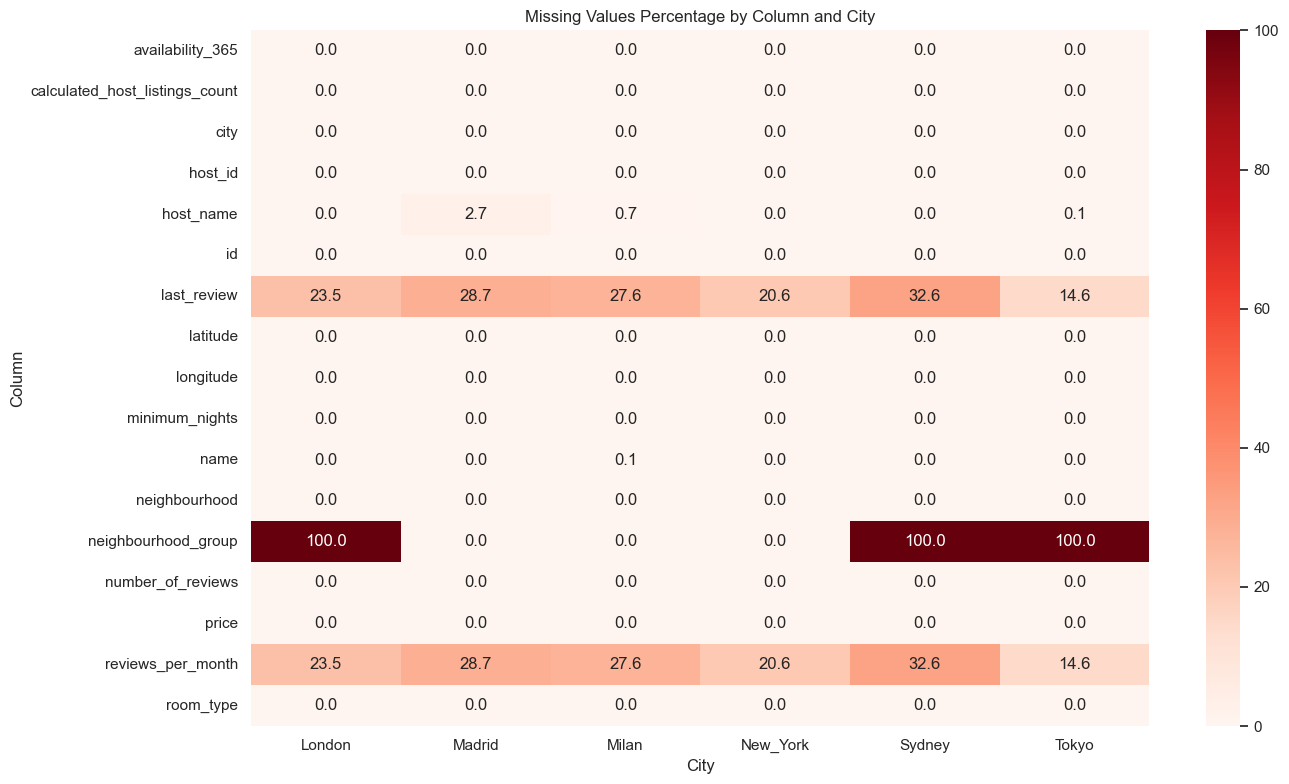

In [35]:
plt.figure(figsize=(14, 8))
sns.heatmap(missing_pivot, annot=True, fmt=".1f", cmap="Reds")
plt.title("Missing Values Percentage by Column and City")
plt.xlabel("City")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

### Interpretation of missing values

The missing values pattern should not be interpreted uniformly.

For example:
- review-related variables may naturally be null for listings with no review history,
- some columns may be absent in specific cities due to schema inconsistency rather than poor data quality,
- and other variables may require explicit business or technical treatment during cleaning.

This distinction will be important when building the preprocessing pipeline.

## 8. Duplicate Detection

Duplicate rows can bias descriptive statistics, distort model training, and reduce trust in the dataset.

At this stage, we inspect whether exact duplicate records exist within each city dataset.

In [36]:
duplicate_summary = pd.DataFrame(
    [
        {
            "city": city,
            "duplicate_rows": df.duplicated().sum(),
            "duplicate_pct": round(df.duplicated().mean() * 100, 4)
        }
        for city, df in dfs.items()
    ]
).sort_values(by="duplicate_rows", ascending=False)

duplicate_summary

,city,duplicate_rows,duplicate_pct
0,Madrid,0,0.00
1,Milan,0,0.00
2,London,0,0.00
3,New_York,0,0.00
4,Sydney,0,0.00
5,Tokyo,0,0.00


### Duplicate analysis

If duplicates are detected, they will need to be reviewed in the preprocessing stage to determine whether they represent:
- true duplicated records,
- repeated snapshots,
- or valid repeated entries according to business context.

At this stage, the goal is simply to quantify their existence.

## 9. Initial Inspection of Key Business Variables

Before launching the full EDA, it is useful to review the variables most likely to drive the business analysis.

The most relevant candidates at this stage are:
- `price`
- `room_type`
- `minimum_nights`
- `number_of_reviews`
- `availability_365` (when available)

This section is not intended to replace the EDA.  
Its goal is to detect obvious structural issues and understand the analytical relevance of the core variables.

In [37]:
key_columns = [
    "price",
    "room_type",
    "minimum_nights",
    "number_of_reviews",
    "availability_365"
]

for city, df in dfs.items():
    print("=" * 100)
    print(f"{city} - Key variables overview")
    available_cols = [col for col in key_columns if col in df.columns]
    display(df[available_cols].describe(include="all"))

Madrid - Key variables overview


,price,room_type,minimum_nights,number_of_reviews,availability_365
count,"19,618.00",19618,"19,618.00","19,618.00","19,618.00"
unique,NaN,4,NaN,NaN,NaN
top,NaN,Entire home/apt,NaN,NaN,NaN
freq,NaN,11314,NaN,NaN,NaN
mean,129.27,NaN,6.59,31.86,159.10
std,484.14,NaN,33.29,63.94,144.25
min,0.00,NaN,1.00,0.00,0.00
25%,35.00,NaN,1.00,0.00,0.00
50%,58.00,NaN,2.00,4.00,126.00
75%,100.00,NaN,3.00,31.00,320.00


Milan - Key variables overview


,price,room_type,minimum_nights,number_of_reviews,availability_365
count,"18,322.00",18322,"18,322.00","18,322.00","18,322.00"
unique,NaN,4,NaN,NaN,NaN
top,NaN,Entire home/apt,NaN,NaN,NaN
freq,NaN,13605,NaN,NaN,NaN
mean,115.09,NaN,5.80,23.72,153.51
std,290.79,NaN,26.69,57.66,138.76
min,8.00,NaN,1.00,0.00,0.00
25%,50.00,NaN,1.00,0.00,0.00
50%,73.50,NaN,2.00,3.00,123.00
75%,110.00,NaN,3.00,19.00,302.00


London - Key variables overview


...

,price,room_type,minimum_nights,number_of_reviews,availability_365
count,"48,895.00",48895,"48,895.00","48,895.00","48,895.00"
unique,NaN,3,NaN,NaN,NaN
top,NaN,Entire home/apt,NaN,NaN,NaN
freq,NaN,25409,NaN,NaN,NaN
mean,152.72,NaN,7.03,23.27,112.78
std,240.15,NaN,20.51,44.55,131.62
min,0.00,NaN,1.00,0.00,0.00
25%,69.00,NaN,1.00,1.00,0.00
50%,106.00,NaN,3.00,5.00,45.00
75%,175.00,NaN,5.00,24.00,227.00


Sydney - Key variables overview


,price,room_type,minimum_nights,number_of_reviews,availability_365
count,"36,662.00",36662,"36,662.00","36,662.00","36,662.00"
unique,NaN,3,NaN,NaN,NaN
top,NaN,Entire home/apt,NaN,NaN,NaN
freq,NaN,22918,NaN,NaN,NaN
mean,207.69,NaN,5.10,12.19,97.39
std,323.82,NaN,15.66,28.65,122.97
min,0.00,NaN,1.00,0.00,0.00
25%,80.00,NaN,1.00,0.00,0.00
50%,136.00,NaN,2.00,2.00,36.00
75%,223.00,NaN,5.00,9.00,165.00


Tokyo - Key variables overview


,price,room_type,minimum_nights,number_of_reviews
count,"11,466.00",11466,"11,466.00","11,466.00"
unique,NaN,3,NaN,NaN
top,NaN,Entire home/apt,NaN,NaN
freq,NaN,7463,NaN,NaN
mean,"14,984.70",NaN,3.32,26.03
std,"33,273.45",NaN,7.77,38.46
min,0.00,NaN,1.00,0.00
25%,"6,026.00",NaN,1.00,2.00
50%,"10,007.00",NaN,1.00,12.00
75%,"17,216.00",NaN,2.00,32.00


### Early analytical notes

The key variable inspection provides an early indication of:
- the central role of price as the likely target variable,
- the importance of room type for segmentation,
- and the value of demand-related metrics such as reviews and availability.

These variables are expected to become central in the exploratory, statistical, and modeling stages of the project.

## 10. Preliminary Consolidation

For inspection purposes only, the city-level datasets are concatenated into a temporary unified DataFrame using the union of available columns.

This is **not yet** the final analytical dataset.  
The objective is simply to support high-level inspection and confirm that a multi-city combined dataset can be constructed after schema harmonization.

In [38]:
df_raw_combined = pd.concat(dfs.values(), ignore_index=True, sort=False)

print("Combined dataset shape:", df_raw_combined.shape)
display(df_raw_combined.head())

Combined dataset shape: (220031, 17)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,6369,"Rooftop terrace room , ensuite bathroom",13660,Simon,Chamartín,Hispanoamérica,40.46,-3.68,Private room,60,1,78,2020-09-20,0.58,1.00,180.00,Madrid
1,21853,Bright and airy room,83531,Abdel,Latina,Cármenes,40.40,-3.74,Private room,31,4,33,2018-07-15,0.42,2.00,364.00,Madrid
2,23001,Apartmento Arganzuela- Madrid Rio,82175,Jesus,Arganzuela,Legazpi,40.39,-3.70,Entire home/apt,50,15,0,NaN,NaN,7.00,1.00,Madrid
3,24805,Gran Via Studio Madrid,346366726,A,Centro,Universidad,40.42,-3.71,Entire home/apt,92,5,10,2020-03-01,0.13,1.00,72.00,Madrid
4,26825,Single Room whith private Bathroom,114340,Agustina,Arganzuela,Legazpi,40.39,-3.69,Private room,26,2,149,2020-03-12,1.12,1.00,365.00,Madrid


In [39]:
df_raw_combined["city"].value_counts()

city
London      85068
New_York    48895
Sydney      36662
Madrid      19618
Milan       18322
Tokyo       11466
Name: count, dtype: int64

## 11. Main Findings

The data understanding phase reveals that the Airbnb datasets are useful and sufficiently rich for a multi-city analytical project, but they also present clear structural challenges.

### Main findings
1. The project includes multiple cities with different dataset sizes.
2. The datasets are not fully homogeneous in terms of available columns.
3. A subset of variables appears consistently across cities and can support a common analytical schema.
4. Missing values are present and should be interpreted according to business context and schema design.
5. Duplicate checks must be incorporated into preprocessing.
6. A formal standardization pipeline is necessary before performing cross-city exploratory analysis and dashboarding.

## 12. Risks and Technical Implications

This notebook identifies several technical implications for the next project phase:

- **Schema harmonization is required** before combining all cities into a clean master table.
- **Column availability differs by city**, meaning some analyses may need to be restricted to a subset of the data.
- **Date parsing and type validation** will be needed before statistical analysis or machine learning.
- **Missing value treatment** must be designed carefully to avoid removing meaningful business information.
- **A clean processed dataset** should be generated and versioned for downstream use in EDA, modeling, and Power BI.

## 13. Next Steps

The next stage of the project will focus on preprocessing and schema standardization.

That work will include:
- defining the common schema,
- standardizing column names and data types,
- treating missing values,
- reviewing duplicates,
- generating derived variables where appropriate,
- and exporting a clean dataset to `data/processed/`.

Once preprocessing is complete, the project will continue with:
1. exploratory data analysis,
2. hypothesis testing,
3. modeling,
4. and dashboard development in Power BI.

## 14. Conclusion

This notebook successfully establishes the analytical baseline of the Airbnb multi-city project.

Rather than jumping directly into visualizations or modeling, this phase documents the actual structure and quality of the raw data, which is essential for professional and reproducible data work.

With the current findings, the project is now ready to move into a formal preprocessing phase.